In [3]:
!pip install rdkit
!pip install torch_geometric
!pip install captum
!pip install deepchem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 14.6 MB/s eta 0:00:00


In [55]:
# Импорт библиотек
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from torch_geometric.nn import GraphConv, global_add_pool, global_mean_pool
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_add_pool, global_mean_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau
from captum.attr import IntegratedGradients
import deepchem as dc
from deepchem.feat.graph_data import GraphData
from deepchem.splits import ScaffoldSplitter
from deepchem.data import NumpyDataset
from deepchem.splits import ScaffoldSplitter
import warnings
warnings.filterwarnings('ignore')
IPythonConsole.ipython_useSVG = True  # Визуализация молекул в SVG

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [56]:
# Загрузка Tox21 напрямую без DeepChem
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Загружаем данные
print("Загрузка данных Tox21...")
tox21_df = pd.read_csv("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz")

# Определяем задачи (12 токсикологических тестов)
tasks = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
         'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']

# Получаем SMILES и метки
smiles_list = tox21_df['smiles'].tolist()
labels_array = tox21_df[tasks].values

# Создаем маску для пропущенных значений и обрабатываем NaN
mask_array = (~np.isnan(labels_array)).astype(int)
labels_array = np.nan_to_num(labels_array, nan=0.0)

print(f"Всего молекул: {len(smiles_list)}")
print(f"Задачи: {tasks}")

# Функция для генерации скелета (scaffold) молекулы
def get_scaffold(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return ""
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffold_smiles = Chem.MolToSmiles(scaffold)
        return scaffold_smiles if scaffold_smiles else ""
    except:
        return ""

# Генерируем скелеты для всех молекул
scaffolds = [get_scaffold(smiles) for smiles in smiles_list]

# Создаем DataFrame для удобства
data_df = pd.DataFrame({
    'smiles': smiles_list,
    'scaffold': scaffolds
})

# Добавляем метки и маску
for i, task in enumerate(tasks):
    data_df[f'y_{task}'] = labels_array[:, i]
    data_df[f'mask_{task}'] = mask_array[:, i]

# Удаляем молекулы с пустыми скелетами
data_df = data_df[data_df['scaffold'] != ""].reset_index(drop=True)
print(f"Молекул после фильтрации: {len(data_df)}")

# Выполняем Scaffold Split вручную
unique_scaffolds = data_df['scaffold'].unique()
np.random.seed(42)
np.random.shuffle(unique_scaffolds)

# Разделение: 80% train, 10% valid, 10% test по скелетам
n_total = len(unique_scaffolds)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_scaffolds = set(unique_scaffolds[:n_train])
valid_scaffolds = set(unique_scaffolds[n_train:n_train + n_valid])
test_scaffolds = set(unique_scaffolds[n_train + n_valid:])

# Разделяем данные
train_df = data_df[data_df['scaffold'].isin(train_scaffolds)].reset_index(drop=True)
valid_df = data_df[data_df['scaffold'].isin(valid_scaffolds)].reset_index(drop=True)
test_df = data_df[data_df['scaffold'].isin(test_scaffolds)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Valid: {len(valid_df)}, Test: {len(test_df)}")

# Функция для извлечения данных из DataFrame
def df_to_dataset(df):
    class Dataset:
        def __init__(self, df, tasks):
            self.ids = df['smiles'].tolist()
            self.y = np.array(df[[f'y_{task}' for task in tasks]])
            self.w = np.array(df[[f'mask_{task}' for task in tasks]])

    return Dataset(df, tasks)

# Создаем датасеты
train_dataset = df_to_dataset(train_df)
valid_dataset = df_to_dataset(valid_df)
test_dataset = df_to_dataset(test_df)

Загрузка данных Tox21...
Всего молекул: 7831
Задачи: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


[14:31:16] WARNING: not removing hydrogen atom without neighbors
[14:31:16] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:31:16] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:31:16] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:31:16] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:31:17] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:31:17] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:31:17] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:31:17] Explicit valence for atom # 20 Al, 6, is greater than permitted


Молекул после фильтрации: 6048
Train: 5217, Valid: 475, Test: 356



Train Dataset Analysis:
         Task  Missing (%) Positive Ratio  Valid Labels
        NR-AR     7.935595          0.053          4803
    NR-AR-LBD    15.391988          0.043          4414
       NR-AhR    18.305540          0.152          4262
 NR-Aromatase    29.212191          0.061          3693
        NR-ER    23.212574          0.150          4006
    NR-ER-LBD    12.765957          0.059          4551
NR-PPAR-gamma    20.509872          0.028          4147
       SR-ARE    28.253786          0.181          3743
     SR-ATAD5    11.079164          0.040          4639
       SR-HSE    19.244777          0.062          4213
       SR-MMP    27.774583          0.196          3768
       SR-p53    15.276979          0.075          4420

Valid Dataset Analysis:
         Task  Missing (%) Positive Ratio  Valid Labels
        NR-AR     8.210526          0.050           436
    NR-AR-LBD    16.421053          0.038           397
       NR-AhR    20.210526          0.174           37

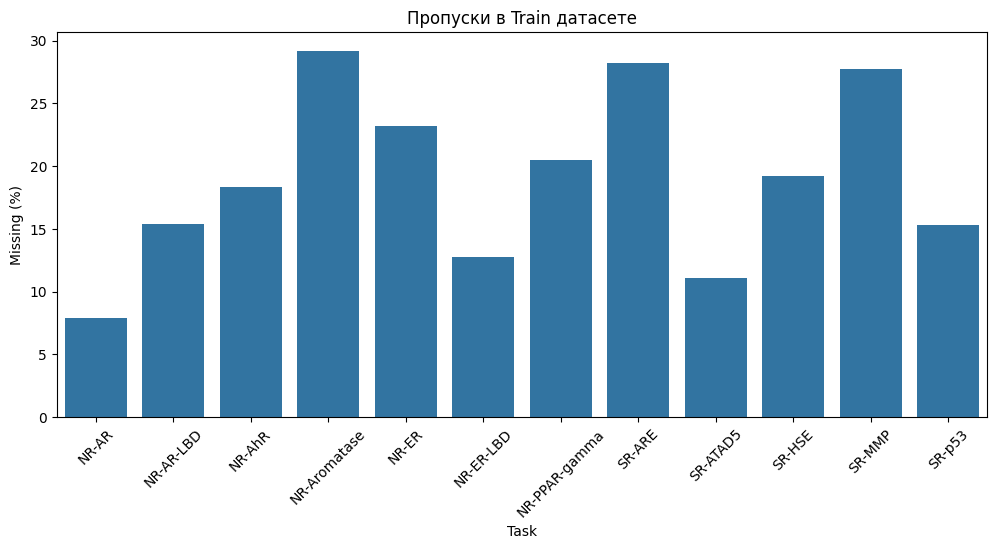

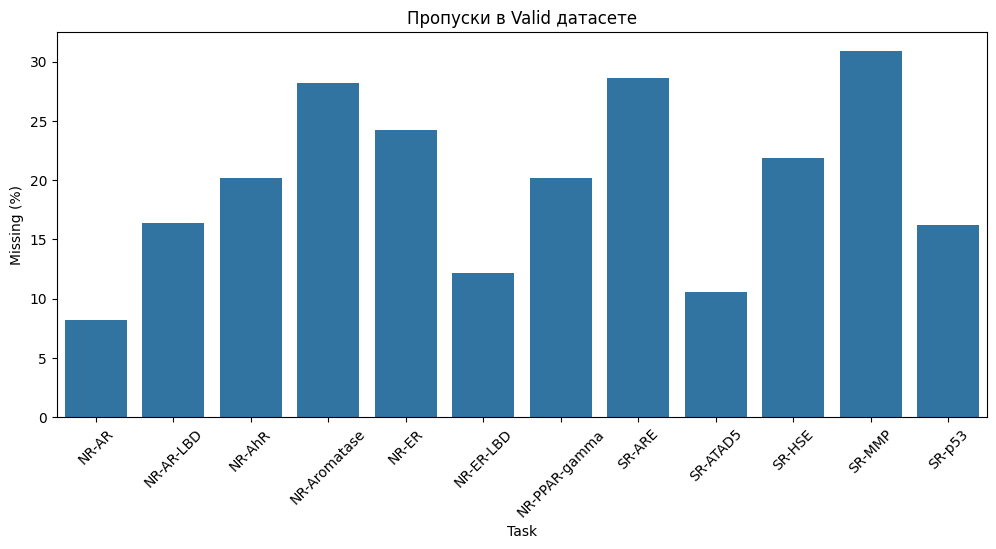

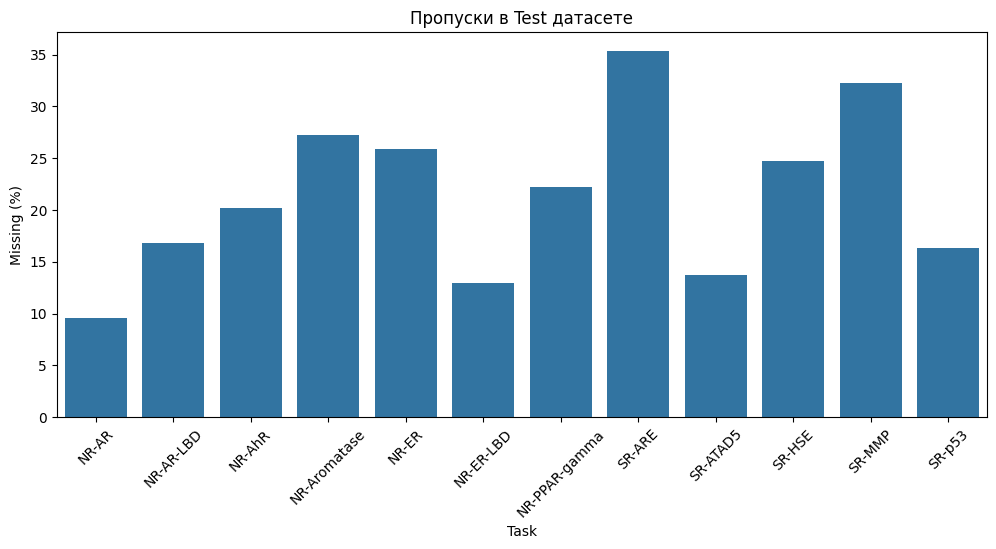

In [57]:
# Анализ данных: пропуски и баланс классов
def analyze_dataset(dataset, name):
    y = dataset.y
    w = dataset.w  # Маска присутствия меток (1.0 = есть метка, 0.0 = нет)

    # Процент пропусков по задачам
    missing_pct = (1 - w.mean(axis=0)) * 100

    # Баланс классов (только для присутствующих меток)
    class_balance = []
    for i in range(y.shape[1]):
        mask = w[:, i] == 1.0
        if np.sum(mask) > 0:
            pos_ratio = np.mean(y[mask, i])
            class_balance.append(f"{pos_ratio:.3f}")
        else:
            class_balance.append("N/A")

    # Создание DataFrame для визуализации
    analysis_df = pd.DataFrame({
        'Task': tasks,
        'Missing (%)': missing_pct,
        'Positive Ratio': class_balance,
        'Valid Labels': w.sum(axis=0).astype(int)
    })

    print(f"\n{name} Dataset Analysis:")
    print(analysis_df.to_string(index=False))

    # Визуализация
    plt.figure(figsize=(12, 5))
    sns.barplot(x='Task', y='Missing (%)', data=analysis_df)
    plt.title(f'Пропуски в {name} датасете')
    plt.xticks(rotation=45)

    return analysis_df

# Анализ всех наборов данных
train_analysis = analyze_dataset(train_dataset, "Train")
valid_analysis = analyze_dataset(valid_dataset, "Valid")
test_analysis = analyze_dataset(test_dataset, "Test")


Примеры молекул из датасета:
Молекула 1: CCOc1ccc2nc(S(N)(=O)=O)sc2c1
Метки токсичности (1=токсична): [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


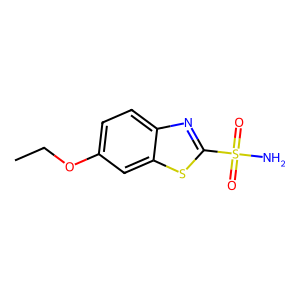

Молекула 2: CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C
Метки токсичности (1=токсична): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


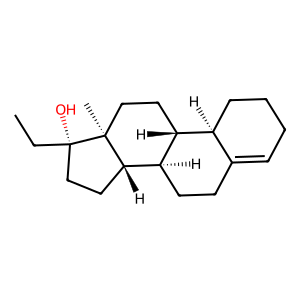

Молекула 3: CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
Метки токсичности (1=токсична): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


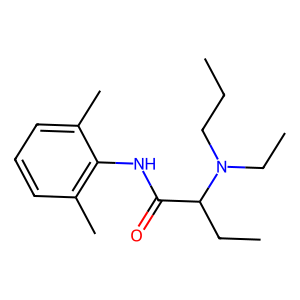

Молекула 4: O=S(=O)(Cl)c1ccccc1
Метки токсичности (1=токсична): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


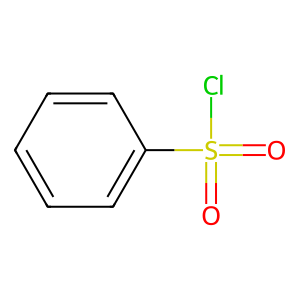

Молекула 5: NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)([O-])OP(=O)(O)OC[C@H]3O[C@@H](n4cnc5c(N)ncnc54)[C@H](O)[C@@H]3O)[C@@H](O)[C@H]2O)c1
Метки токсичности (1=токсична): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


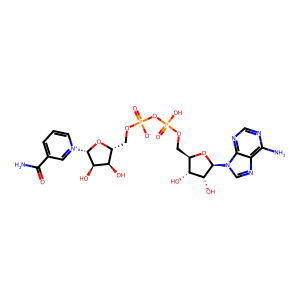

In [58]:
# Визуализация примеров молекул
smiles_samples = train_dataset.ids[:5]  # Первые 5 SMILES из train
mols = [Chem.MolFromSmiles(s) for s in smiles_samples]
labels = train_dataset.y[:5]

print("Примеры молекул из датасета:")
for i, (mol, label) in enumerate(zip(mols, labels)):
    print(f"Молекула {i+1}: {smiles_samples[i]}")
    print("Метки токсичности (1=токсична):", label)
    display(Draw.MolToImage(mol, size=(300, 300)))

In [59]:
# Функция преобразования SMILES в граф PyG
def smiles_to_pyg_data(smiles, y=None, mask=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    node_features = []
    edge_index = []

    allowable_atoms = ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'Other']
    atom_to_idx = {atom: i for i, atom in enumerate(allowable_atoms)}

    for atom in mol.GetAtoms():
        atom_symbol = atom.GetSymbol()
        atom_idx = atom_to_idx.get(atom_symbol, atom_to_idx['Other'])
        atom_onehot = [0] * len(allowable_atoms)
        atom_onehot[atom_idx] = 1

        features = atom_onehot + [
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.IsInRing()),
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic()),
            atom.GetImplicitValence()
        ]
        node_features.append(features)

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.empty((2, 0), dtype=torch.long)

    y_tensor = torch.tensor(y, dtype=torch.float) if y is not None else None
    mask_tensor = torch.tensor(mask, dtype=torch.bool) if mask is not None else None

    return Data(x=x, edge_index=edge_index, y=y_tensor, mask=mask_tensor, smiles=smiles)


In [60]:
# Преобразование датасетов в формат PyG
def convert_to_pyg(dataset):
    pyg_data_list = []
    for i in range(len(dataset.ids)):
        smiles = dataset.ids[i]
        y = dataset.y[i]
        mask = dataset.w[i]  # Маска присутствия меток

        data = smiles_to_pyg_data(smiles, y, mask)
        if data is not None:
            pyg_data_list.append(data)
    return pyg_data_list

# Преобразование всех наборов
train_data = convert_to_pyg(train_dataset)
valid_data = convert_to_pyg(valid_dataset)
test_data = convert_to_pyg(test_dataset)


Выходные данные были обрезаны до нескольких последних строк (5000).
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[14:31:29] DEPRECATION WARNING: please use GetValence(ge

In [61]:
# Подготовка DataLoader
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

# Пример батча
sample_batch = next(iter(train_loader))
print("\nПример батча:")
print(f"x.shape: {sample_batch.x.shape}")
print(f"edge_index.shape: {sample_batch.edge_index.shape}")
print(f"y.shape: {sample_batch.y.shape}")
print(f"mask.shape: {sample_batch.mask.shape}")



Пример батча:
x.shape: torch.Size([620, 16])
edge_index.shape: torch.Size([2, 1310])
y.shape: torch.Size([384])
mask.shape: torch.Size([384])


In [62]:
# Расчет весов классов для балансировки
def compute_class_weights(dataset):
    y = dataset.y
    w = dataset.w

    weights = []
    for task_idx in range(y.shape[1]):
        task_mask = w[:, task_idx] == 1.0
        if np.sum(task_mask) == 0:
            weights.append(1.0)
            continue

        task_labels = y[task_mask, task_idx]
        num_pos = np.sum(task_labels)
        num_neg = len(task_labels) - num_pos

        # Защита от деления на ноль
        if num_pos == 0:
            weight = 1.0
        elif num_neg == 0:
            weight = 1.0
        else:
            weight = num_neg / num_pos
        weights.append(min(weight, 10.0))  # Ограничение максимального веса

    return torch.tensor(weights, dtype=torch.float)

# Вычисление весов на обучающей выборке
class_weights = compute_class_weights(train_dataset).to(device)
print("Веса классов:", class_weights.cpu().numpy())

Веса классов: [10.        10.         5.597523  10.         5.6766667 10.
 10.         4.5125184 10.        10.         4.105691  10.       ]


In [73]:
# Определение модели GNN
class Tox21GNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim=256,
                 num_tasks=12, num_layers=4, dropout=0.3, pool_type='add'):
        super().__init__()
        self.dropout = dropout
        self.pool_type = pool_type

        self.node_encoder = nn.Linear(node_feat_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))

        self.pool = global_add_pool if pool_type == 'add' else global_mean_pool
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_tasks)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.node_encoder(x)

        for conv, bn in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.pool(x, batch)
        return self.fc(x)

# Инициализация модели
node_feat_dim = train_data[0].x.shape[1]

model = Tox21GNN(
    node_feat_dim=node_feat_dim,
    hidden_dim=256,
    num_tasks=12,
    num_layers=4,
    dropout=0.3,
    pool_type='add'
).to(device)

print(model)


Tox21GNN(
  (node_encoder): Linear(in_features=16, out_features=256, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GCNConv(256, 256)
  )
  (batch_norms): ModuleList(
    (0-3): 4 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=12, bias=True)
  )
)


In [74]:
# Функция потерь с учетом маски и весов классов
def masked_bce_loss(logits, targets, mask, pos_weights=None):
    if pos_weights is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights, reduction='none')
    else:
        criterion = nn.BCEWithLogitsLoss(reduction='none')

    loss = criterion(logits, targets)
    loss = loss * mask  # Маскирование пропущенных значений

    # Усреднение только по присутствующим меткам
    return loss.sum() / mask.sum()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Функция оценки метрик
def evaluate(loader, model, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data)
            preds = torch.sigmoid(logits)

            batch_size = preds.size(0)

            # Восстанавливаем форму меток и маски
            targets = data.y.view(batch_size, -1)
            masks = data.mask.float().view(batch_size, -1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_masks.append(masks.cpu().numpy())

    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    masks = np.vstack(all_masks)

    # Расчет метрик по каждой задаче
    task_roc_aucs = []
    task_pr_aucs = []

    for task_idx in range(targets.shape[1]):
        task_mask = masks[:, task_idx].astype(bool)
        if np.sum(task_mask) == 0:
            continue

        task_targets = targets[task_mask, task_idx]
        task_preds = preds[task_mask, task_idx]

        # ROC-AUC
        try:
            roc_auc = roc_auc_score(task_targets, task_preds)
        except ValueError:  # если только один класс
            roc_auc = 0.5

        # PR-AUC
        try:
            pr_auc = average_precision_score(task_targets, task_preds)
        except ValueError:
            pr_auc = 0.0

        task_roc_aucs.append(roc_auc)
        task_pr_aucs.append(pr_auc)

    # Усреднение по задачам
    macro_roc_auc = np.mean(task_roc_aucs) if task_roc_aucs else 0.5
    macro_pr_auc = np.mean(task_pr_aucs) if task_pr_aucs else 0.0

    return macro_roc_auc, macro_pr_auc, task_roc_aucs, task_pr_aucs


In [75]:
# Обучение модели
num_epochs = 100
patience = 15
best_val_roc = 0.0
epochs_no_improve = 0

train_losses = []
val_roc_aucs = []
val_pr_aucs = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    num_batches = 0

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        logits = model(data)
        batch_size = logits.size(0)

        y = data.y.view(batch_size, -1)
        mask = data.mask.float().view(batch_size, -1)

        loss = masked_bce_loss(
            logits,
            y,
            mask,
            pos_weights=class_weights
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    train_loss = total_loss / num_batches
    train_losses.append(train_loss)

    val_roc, val_pr, _, _ = evaluate(valid_loader, model, device)
    val_roc_aucs.append(val_roc)
    val_pr_aucs.append(val_pr)

    print(f'Epoch {epoch+1:03d}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val ROC-AUC: {val_roc:.4f} | '
          f'Val PR-AUC: {val_pr:.4f}')

    if val_roc > best_val_roc:
        best_val_roc = val_roc
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

    scheduler.step(val_roc)

model.load_state_dict(torch.load('best_model.pth'))

Epoch 001/100 | Train Loss: 1.0720 | Val ROC-AUC: 0.6895 | Val PR-AUC: 0.2786
Epoch 002/100 | Train Loss: 0.9282 | Val ROC-AUC: 0.7199 | Val PR-AUC: 0.3349
Epoch 003/100 | Train Loss: 0.9130 | Val ROC-AUC: 0.7283 | Val PR-AUC: 0.3778
Epoch 004/100 | Train Loss: 0.8630 | Val ROC-AUC: 0.7362 | Val PR-AUC: 0.3853
Epoch 005/100 | Train Loss: 0.8522 | Val ROC-AUC: 0.6747 | Val PR-AUC: 0.3090
Epoch 006/100 | Train Loss: 0.8425 | Val ROC-AUC: 0.7611 | Val PR-AUC: 0.3983
Epoch 007/100 | Train Loss: 0.8326 | Val ROC-AUC: 0.7560 | Val PR-AUC: 0.3320
Epoch 008/100 | Train Loss: 0.8195 | Val ROC-AUC: 0.7710 | Val PR-AUC: 0.4214
Epoch 009/100 | Train Loss: 0.8250 | Val ROC-AUC: 0.7640 | Val PR-AUC: 0.4021
Epoch 010/100 | Train Loss: 0.8171 | Val ROC-AUC: 0.7275 | Val PR-AUC: 0.3571
Epoch 011/100 | Train Loss: 0.8278 | Val ROC-AUC: 0.7337 | Val PR-AUC: 0.3132
Epoch 012/100 | Train Loss: 0.8011 | Val ROC-AUC: 0.7702 | Val PR-AUC: 0.4309
Epoch 013/100 | Train Loss: 0.7974 | Val ROC-AUC: 0.7733 | Val P

<All keys matched successfully>

In [76]:
# Оценка на тестовом наборе
test_roc, test_pr, task_roc_aucs, task_pr_aucs = evaluate(test_loader, model, device)
print(f"\nТестовые метрики:")
print(f"ROC-AUC: {test_roc:.4f}")
print(f"PR-AUC: {test_pr:.4f}")

# Анализ чувствительности (Recall) и специфичности
def calculate_sensitivity_specificity(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred_bin, labels=[0, 1]
    ).ravel()
    sensitivity = tp / (tp + fn + 1e-8)  # Recall
    specificity = tn / (tn + fp + 1e-8)
    return sensitivity, specificity

sensitivities = []
specificities = []

model.eval()
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        logits = model(data)
        preds = torch.sigmoid(logits).cpu().numpy()
        try:
            targets = torch.unflatten(data.y, dim=0, sizes=(32, 12)).cpu()
            masks = torch.unflatten(data.mask, dim=0, sizes=(32, 12)).cpu()
        except:
            targets = torch.unflatten(data.y, dim=0, sizes=(4, 12)).cpu()
            masks = torch.unflatten(data.mask, dim=0, sizes=(4, 12)).cpu()

        for i in range(len(targets)):
            for task_idx in range(12):
                if masks[i, task_idx]:
                    y_true = targets[i, task_idx]
                    y_pred = preds[i, task_idx]
                    sens, spec = calculate_sensitivity_specificity(
                        np.array([y_true]),
                        np.array([y_pred])
                    )
                    if not np.isnan(sens):
                        sensitivities.append(sens)
                    if not np.isnan(spec):
                        specificities.append(spec)

print(f"\nRecall: {np.mean(sensitivities):.4f}")
print(f"Specificity: {np.mean(specificities):.4f}")


Тестовые метрики:
ROC-AUC: 0.7575
PR-AUC: 0.3963

Recall: 0.0444
Specificity: 0.7869


In [77]:
from rdkit.Chem import AllChem
from torch.utils.data import TensorDataset, DataLoader

# Функция для извлечения Morgan fingerprints
def get_morgan_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp, dtype=np.float32)

# Подготовка данных: получаем отпечатки и метки
def prepare_fp_dataset(df, tasks):
    X = np.array([get_morgan_fingerprint(s) for s in df['smiles']])
    y = np.array(df[[f'y_{task}' for task in tasks]], dtype=np.float32)
    w = np.array(df[[f'mask_{task}' for task in tasks]], dtype=np.float32)
    return X, y, w

print("\nПодготовка данных для Fingerprint + MLP...")
X_train, y_train, w_train = prepare_fp_dataset(train_df, tasks)
X_valid, y_valid, w_valid = prepare_fp_dataset(valid_df, tasks)
X_test,  y_test,  w_test  = prepare_fp_dataset(test_df, tasks)

# Преобразуем в тензоры
X_train_t = torch.tensor(X_train).to(device)
y_train_t = torch.tensor(y_train).to(device)
w_train_t = torch.tensor(w_train).to(device)

X_valid_t = torch.tensor(X_valid).to(device)
y_valid_t = torch.tensor(y_valid).to(device)
w_valid_t = torch.tensor(w_valid).to(device)

X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).to(device)
w_test_t = torch.tensor(w_test).to(device)

# DataLoader для MLP
mlp_batch_size = 32
train_fp_loader = DataLoader(TensorDataset(X_train_t, y_train_t, w_train_t), batch_size=mlp_batch_size, shuffle=True)
valid_fp_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t, w_valid_t), batch_size=mlp_batch_size)
test_fp_loader  = DataLoader(TensorDataset(X_test_t, y_test_t, w_test_t), batch_size=mlp_batch_size)


Подготовка данных для Fingerprint + MLP...


Выходные данные были обрезаны до нескольких последних строк (5000).
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use MorganGenerator
[14:36:25] DEPRECATION WARNING: please use Morg

In [81]:
# Определяем MLP
class FingerprintMLP(nn.Module):
    def __init__(self, input_dim=1024, hidden1=512, hidden2=256, num_tasks=12, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_tasks)
        )
    def forward(self, x):
        return self.net(x)

# Инициализация и обучение
mlp_model = FingerprintMLP().to(device)
optimizer_mlp = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_mlp = ReduceLROnPlateau(optimizer_mlp, mode='max', factor=0.5, patience=5)

# Веса классов (уже посчитаны выше: class_weights)
class_weights_mlp = class_weights  # те же веса, что и для GNN

# Функция потерь (аналогично)
def masked_bce_loss_mlp(logits, targets, mask, pos_weights=None):
    if pos_weights is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights, reduction='none')
    else:
        criterion = nn.BCEWithLogitsLoss(reduction='none')
    loss = criterion(logits, targets)
    loss = loss * mask
    return loss.sum() / mask.sum()

# Функция оценки (аналогично evaluate, но для тензоров)
def evaluate_mlp(loader, model, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []
    with torch.no_grad():
        for X, y, w in loader:
            X, y, w = X.to(device), y.to(device), w.to(device)
            logits = model(X)
            preds = torch.sigmoid(logits)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())
            all_masks.append(w.cpu().numpy())
    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    masks = np.vstack(all_masks)

    task_roc_aucs = []
    task_pr_aucs = []
    for task_idx in range(targets.shape[1]):
        task_mask = masks[:, task_idx].astype(bool)
        if np.sum(task_mask) == 0:
            continue
        task_targets = targets[task_mask, task_idx]
        task_preds = preds[task_mask, task_idx]
        try:
            roc_auc = roc_auc_score(task_targets, task_preds)
        except ValueError:
            roc_auc = 0.5
        try:
            pr_auc = average_precision_score(task_targets, task_preds)
        except ValueError:
            pr_auc = 0.0
        task_roc_aucs.append(roc_auc)
        task_pr_aucs.append(pr_auc)

    macro_roc_auc = np.mean(task_roc_aucs) if task_roc_aucs else 0.5
    macro_pr_auc = np.mean(task_pr_aucs) if task_pr_aucs else 0.0
    return macro_roc_auc, macro_pr_auc, task_roc_aucs, task_pr_aucs

In [82]:
# Обучение MLP
print("\nОбучение Fingerprint + MLP...")
num_epochs_mlp = 100
patience_mlp = 100
best_val_roc_mlp = 0.0
epochs_no_improve_mlp = 0

train_losses_mlp = []
val_roc_aucs_mlp = []
val_pr_aucs_mlp = []

for epoch in range(num_epochs_mlp):
    mlp_model.train()
    total_loss = 0
    num_batches = 0
    for X, y, w in train_fp_loader:
        X, y, w = X.to(device), y.to(device), w.to(device)
        optimizer_mlp.zero_grad()
        logits = mlp_model(X)
        loss = masked_bce_loss_mlp(logits, y, w, pos_weights=class_weights_mlp)
        loss.backward()
        optimizer_mlp.step()
        total_loss += loss.item()
        num_batches += 1
    train_loss = total_loss / num_batches
    train_losses_mlp.append(train_loss)

    val_roc, val_pr, _, _ = evaluate_mlp(valid_fp_loader, mlp_model, device)
    val_roc_aucs_mlp.append(val_roc)
    val_pr_aucs_mlp.append(val_pr)

    print(f'Epoch {epoch+1:03d}/{num_epochs_mlp} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val ROC-AUC: {val_roc:.4f} | '
          f'Val PR-AUC: {val_pr:.4f}')

    if val_roc > best_val_roc_mlp:
        best_val_roc_mlp = val_roc
        epochs_no_improve_mlp = 0
        torch.save(mlp_model.state_dict(), 'best_mlp_model.pth')
    else:
        epochs_no_improve_mlp += 1
        if epochs_no_improve_mlp >= patience_mlp:
            print(f"Ранняя остановка MLP на эпохе {epoch+1}")
            break
    scheduler_mlp.step(val_roc)

mlp_model.load_state_dict(torch.load('best_mlp_model.pth'))


Обучение Fingerprint + MLP...
Epoch 001/100 | Train Loss: 0.9259 | Val ROC-AUC: 0.7285 | Val PR-AUC: 0.4033
Epoch 002/100 | Train Loss: 0.7194 | Val ROC-AUC: 0.7367 | Val PR-AUC: 0.4244
Epoch 003/100 | Train Loss: 0.5681 | Val ROC-AUC: 0.7527 | Val PR-AUC: 0.4386
Epoch 004/100 | Train Loss: 0.4410 | Val ROC-AUC: 0.7377 | Val PR-AUC: 0.4243
Epoch 005/100 | Train Loss: 0.3522 | Val ROC-AUC: 0.7209 | Val PR-AUC: 0.4007
Epoch 006/100 | Train Loss: 0.2768 | Val ROC-AUC: 0.7308 | Val PR-AUC: 0.4159
Epoch 007/100 | Train Loss: 0.2353 | Val ROC-AUC: 0.7228 | Val PR-AUC: 0.4036
Epoch 008/100 | Train Loss: 0.1935 | Val ROC-AUC: 0.7283 | Val PR-AUC: 0.4125
Epoch 009/100 | Train Loss: 0.1623 | Val ROC-AUC: 0.7216 | Val PR-AUC: 0.3952
Epoch 010/100 | Train Loss: 0.1286 | Val ROC-AUC: 0.7256 | Val PR-AUC: 0.4128
Epoch 011/100 | Train Loss: 0.1069 | Val ROC-AUC: 0.7227 | Val PR-AUC: 0.4077
Epoch 012/100 | Train Loss: 0.0993 | Val ROC-AUC: 0.7201 | Val PR-AUC: 0.4028
Epoch 013/100 | Train Loss: 0.088

<All keys matched successfully>

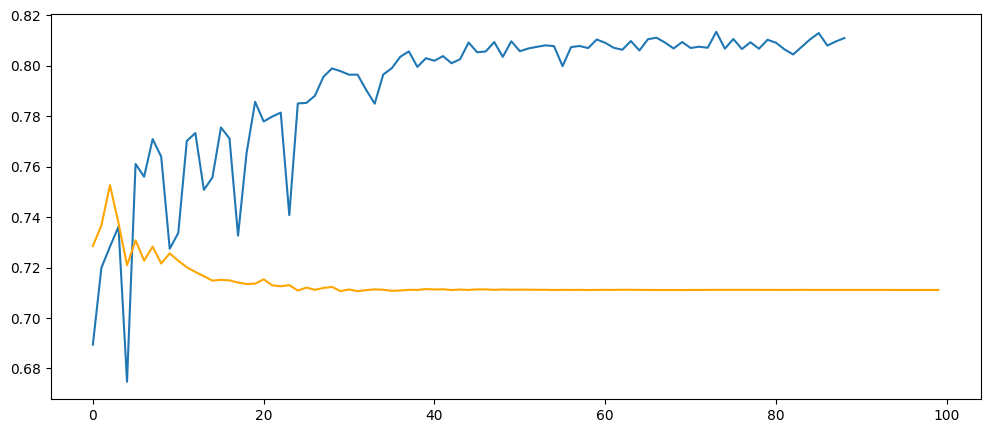

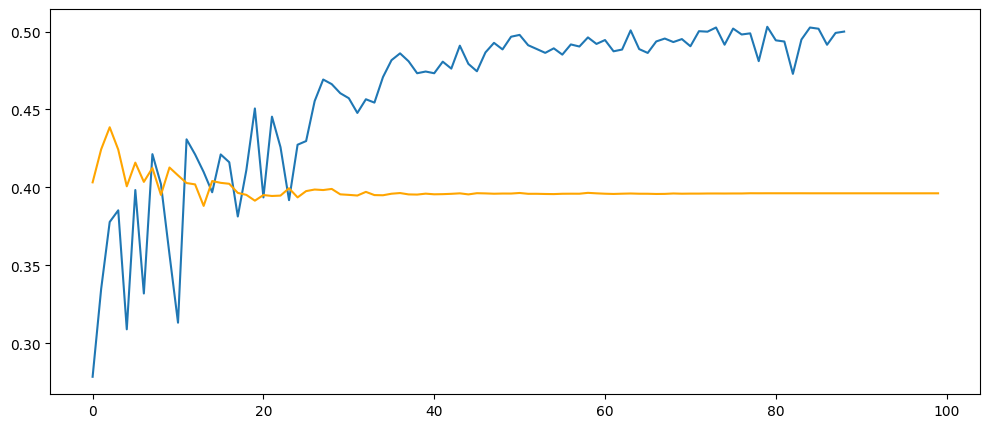

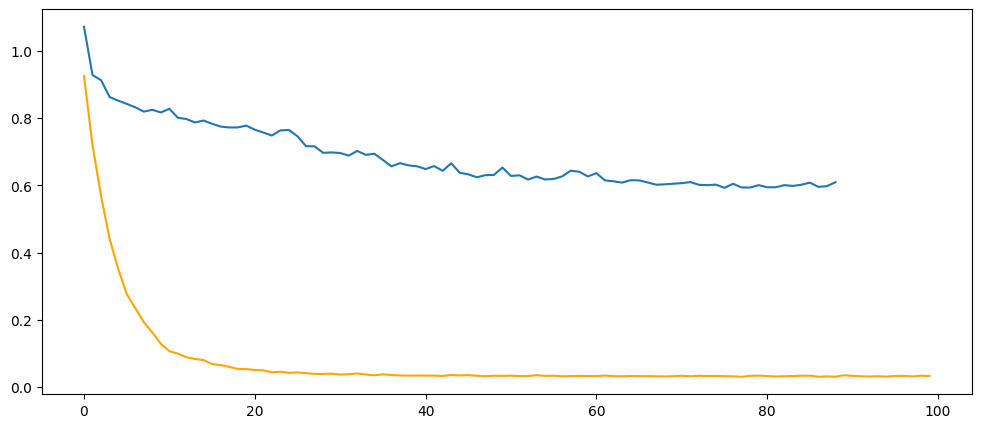


=== СРАВНЕНИЕ МОДЕЛЕЙ ===
GNN Test ROC-AUC: 0.7575
MLP Test ROC-AUC: 0.6959
GNN Test PR-AUC:  0.3963
MLP Test PR-AUC:  0.3015


In [83]:
# Тестирование MLP
test_roc_mlp, test_pr_mlp, task_roc_aucs_mlp, task_pr_aucs_mlp = evaluate_mlp(test_fp_loader, mlp_model, device)

plt.figure(figsize=(12, 5))
plt.plot(val_roc_aucs, label='Val ROC-AUC')
plt.plot(val_roc_aucs_mlp, label='Val ROC-AUC MLP', color='orange')
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(val_pr_aucs, label='Val PR-AUC')
plt.plot(val_pr_aucs_mlp, label='Val PR-AUC MLP', color='orange')
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(train_losses_mlp, label='Train loss MLP', color='orange')
plt.show()

# Сравнение
print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(f"GNN Test ROC-AUC: {test_roc:.4f}")
print(f"MLP Test ROC-AUC: {test_roc_mlp:.4f}")
print(f"GNN Test PR-AUC:  {test_pr:.4f}")
print(f"MLP Test PR-AUC:  {test_pr_mlp:.4f}")